<img src="https://devra.ai/analyst/notebook/4334/image.jpg" style="width: 100%; height: auto;" />

## Table of Contents

1. [Introduction](#Introduction)
2. [Data Loading](#Data-Loading)
3. [Data Cleaning and Preprocessing](#Data-Cleaning-and-Preprocessing)
4. [Exploratory Data Analysis](#Exploratory-Data-Analysis)
5. [Modeling and Prediction](#Modeling-and-Prediction)
6. [Conclusion](#Conclusion)

## Introduction

This notebook explores the Heart Attack Data Set, a dataset that carries the potential to reveal surprising insights into cardiovascular risk factors. It is intriguing to consider how numerical data and clinical features can be transformed into actionable predictions.

In [2]:
# Import necessary libraries and suppress warnings
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc


## Data Loading

In [3]:
# Load the dataset

df = pd.read_csv(r"../data/HeartData.csv")

In [4]:
# Display the first 5 rows to get an initial understanding
print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


In [5]:
# Display dataframe information
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None


## Data Cleaning and Preprocessing

Here we inspect the data for inconsistencies, missing values, and ensure the data types are correctly inferred. In this data set all columns are numeric, however, it's always good practice to verify.

In [6]:
# Check for missing values
missing_values = df.isnull().sum()
print('Missing values in each column:')
print(missing_values)

# Convert columns to appropriate dtypes if necessary
# In this dataset all columns should be of numeric type, but if needed:
numeric_columns = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors='coerce')

# After conversion, check one more time for any NaN that might have been introduced
print('Missing values after conversion:')
print(df.isnull().sum())

Missing values in each column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
Missing values after conversion:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


## Exploratory Data Analysis

This section is dedicated to visualizing the dataset to uncover patterns and relationships amongst the features. In our analysis we include a variety of visualizations such as histograms, pair plots, box plots and a correlation heatmap. Note that we limit our correlation analysis to numeric columns using `df.select_dtypes(include=[np.number])`.

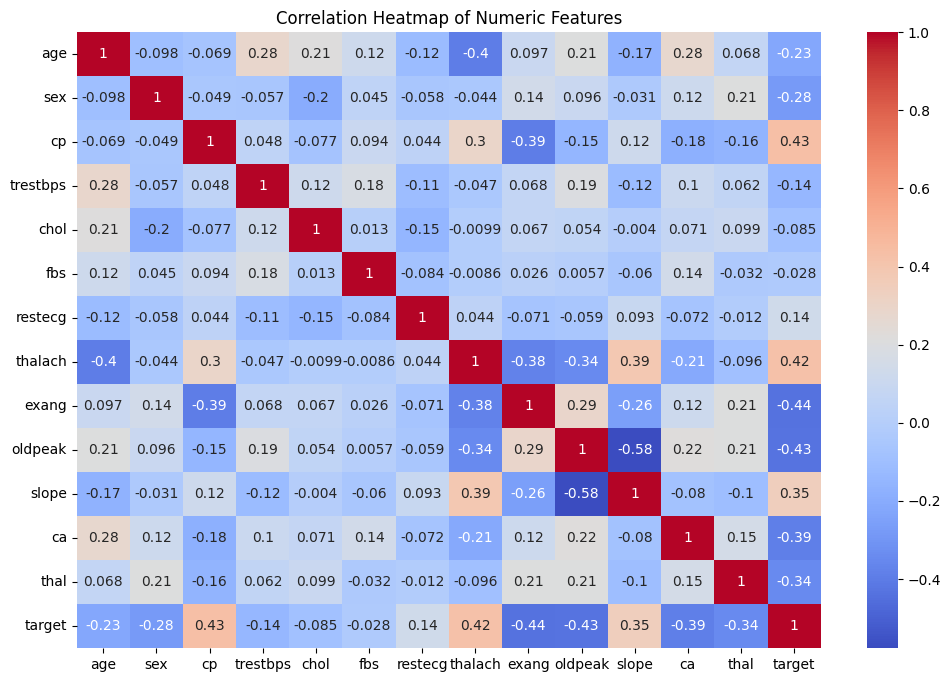

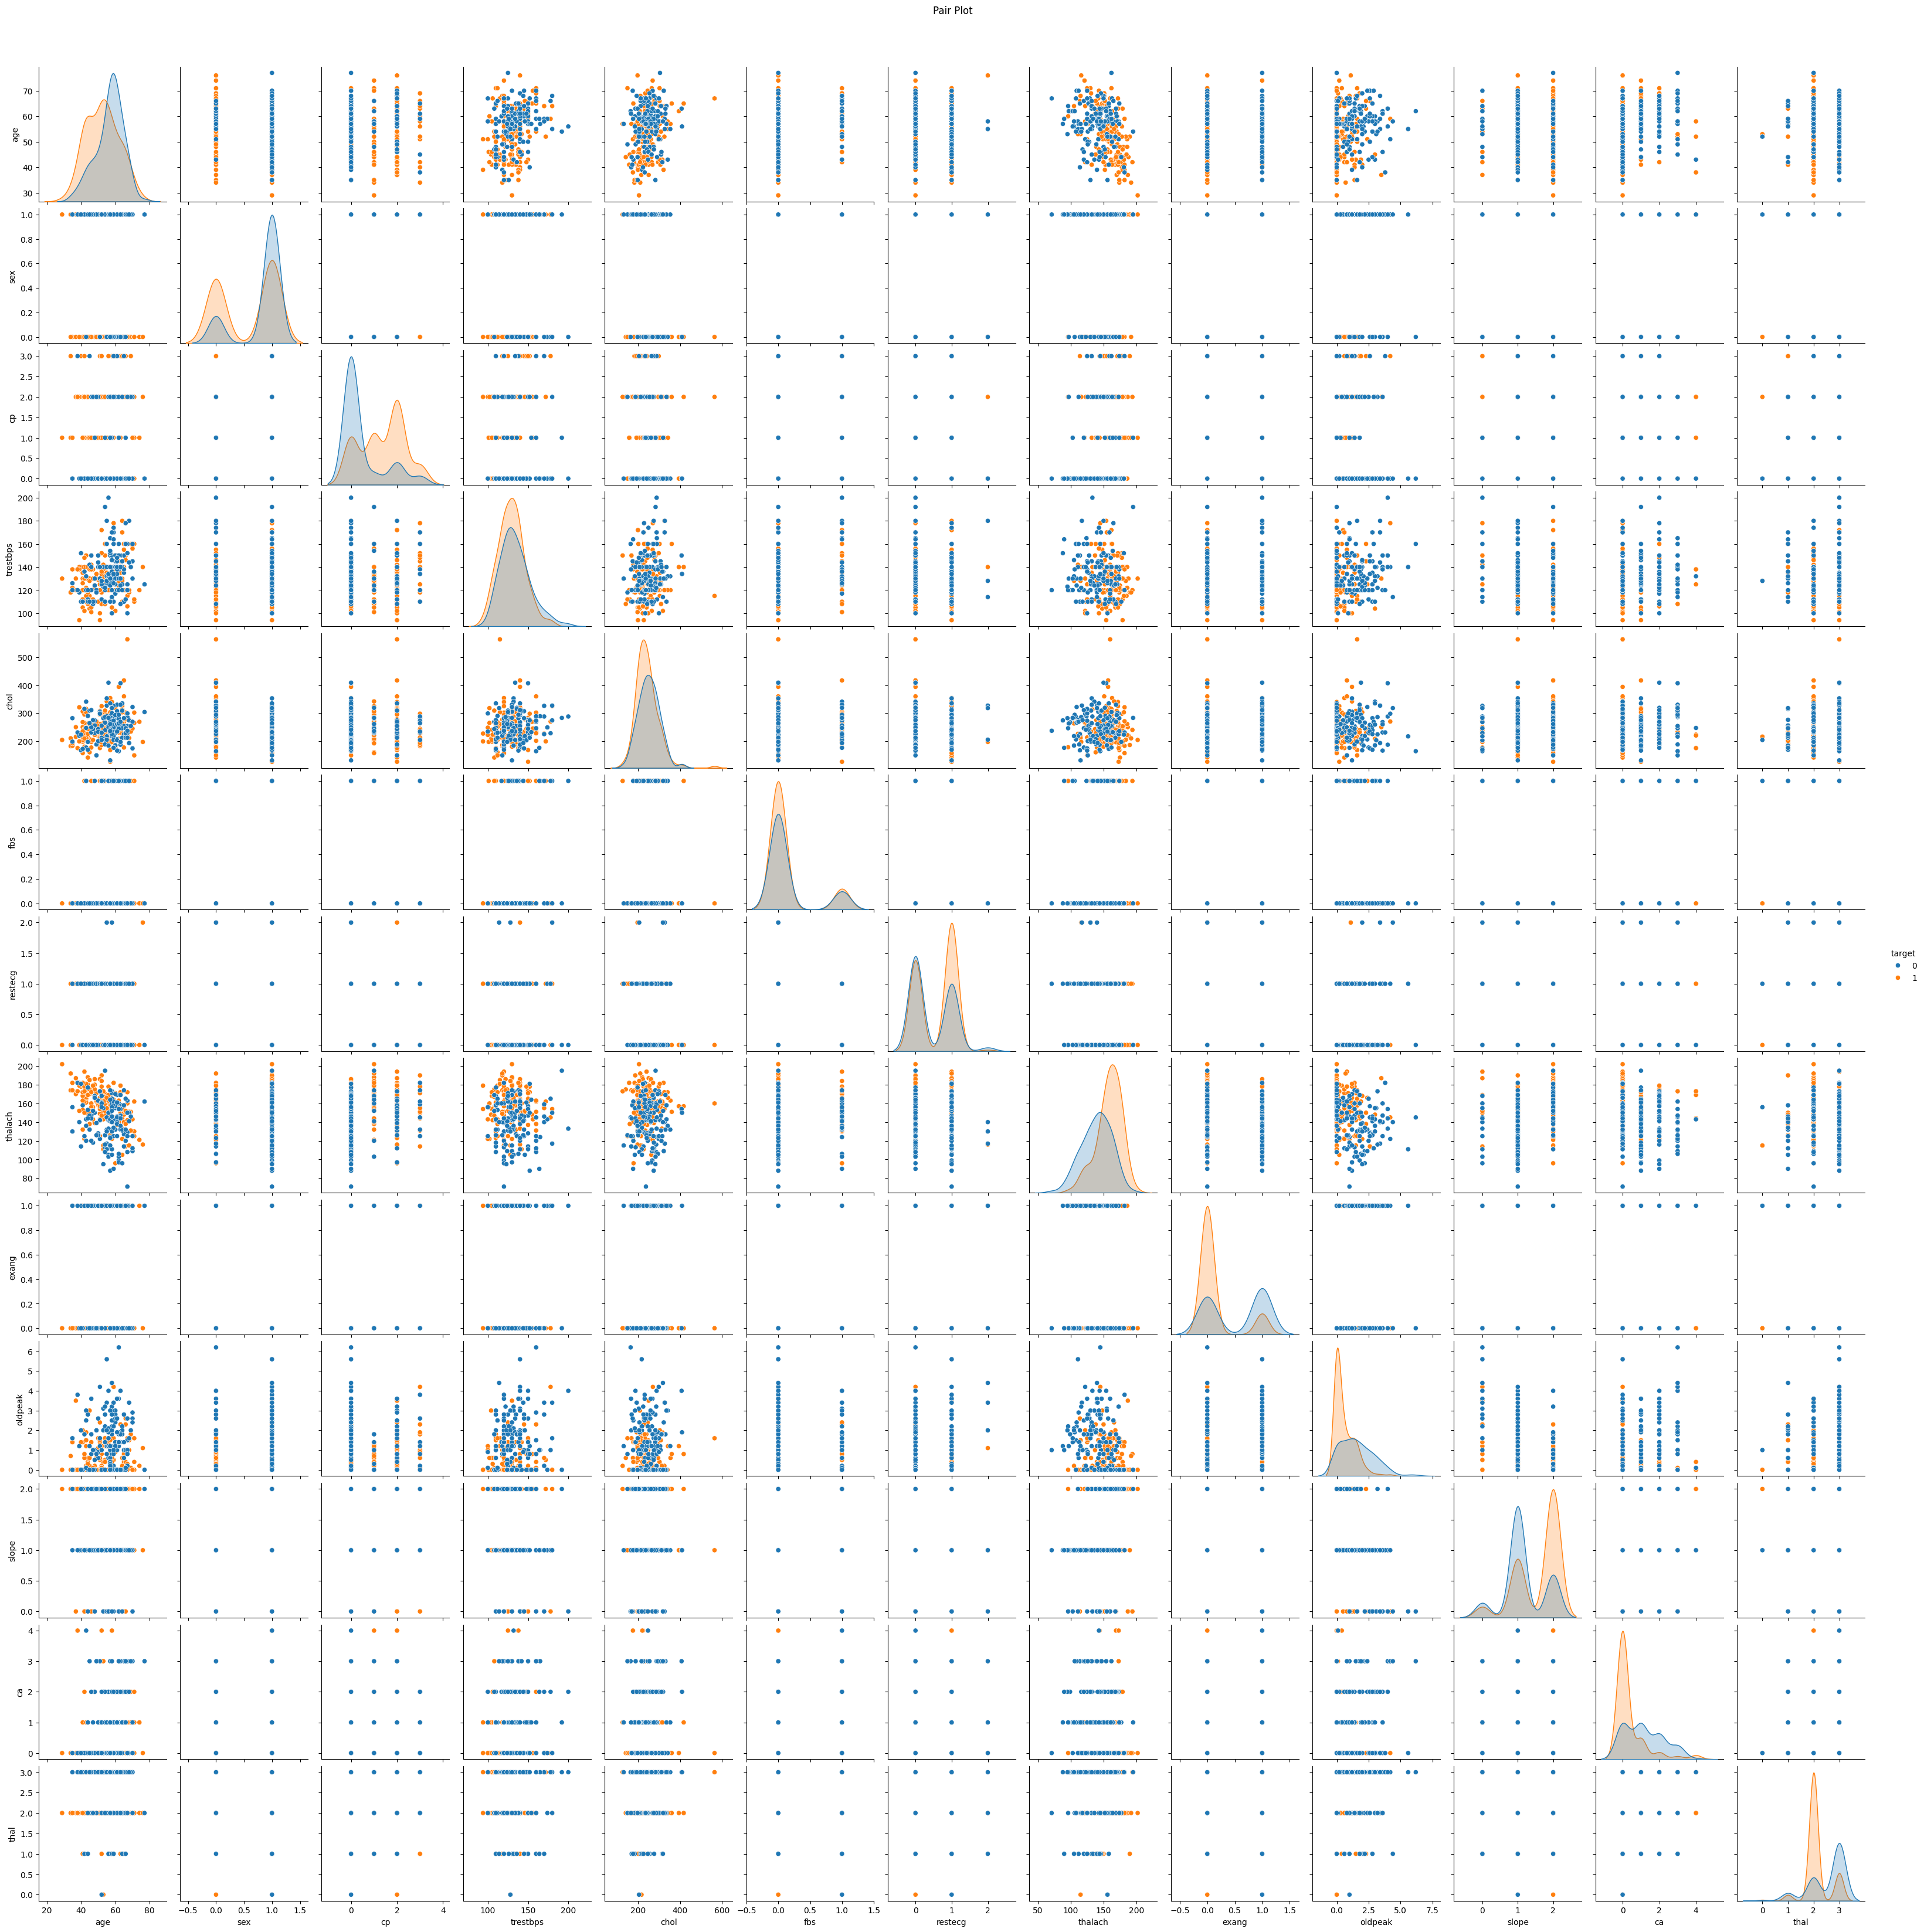

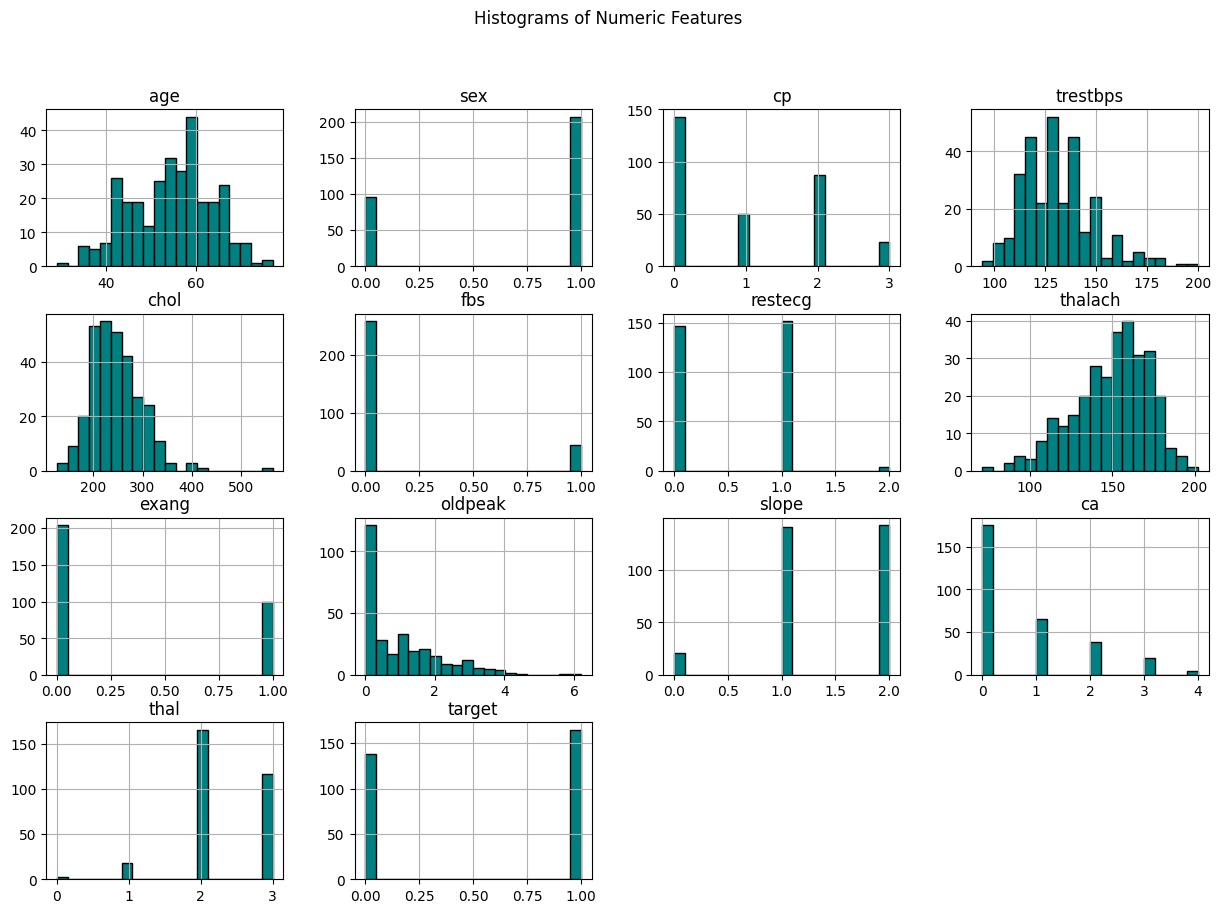

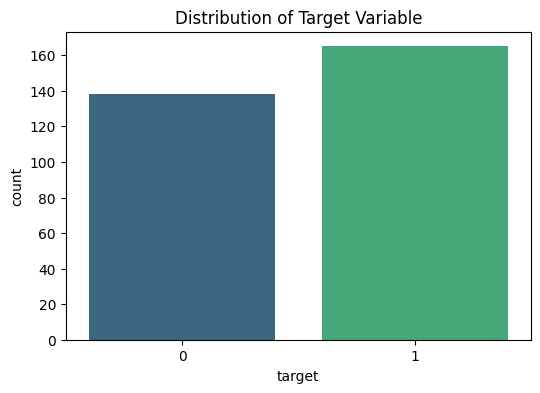

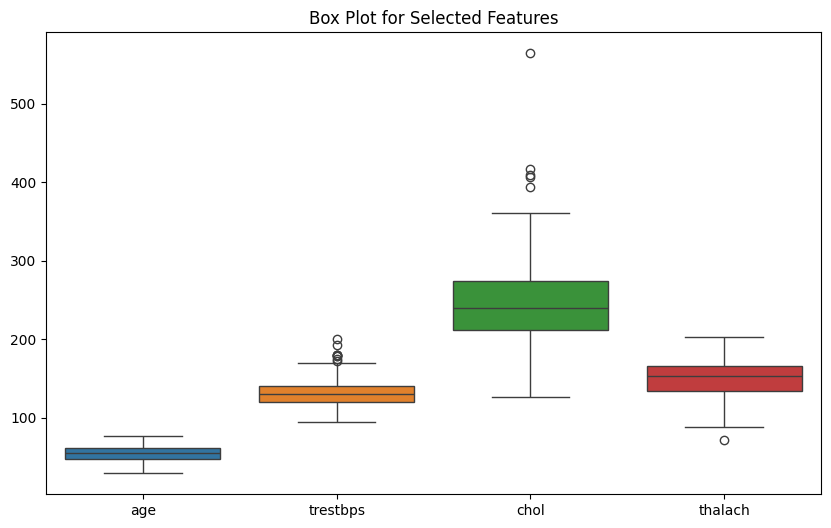

In [7]:
# Extract only numerical columns for correlation heatmap
numeric_df = df.select_dtypes(include=[np.number])

# Plot a correlation heatmap if there are four or more numeric columns
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(12, 8))
    correlation_matrix = numeric_df.corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.show()

# Pair Plot of the dataset
sns.pairplot(df, hue='target')
plt.suptitle('Pair Plot', y=1.02)
plt.show()

# Histograms for each numeric feature
df.hist(bins=20, figsize=(15, 10), color='teal', edgecolor='black')
plt.suptitle('Histograms of Numeric Features')
plt.show()

# Count Plot (Pie Chart alternative) for the target variable
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df, palette='viridis')
plt.title('Distribution of Target Variable')
plt.show()

# Additional visualizations: Box Plot for selected features
plt.figure(figsize=(10,6))
sns.boxplot(data=df[['age', 'trestbps', 'chol', 'thalach']])
plt.title('Box Plot for Selected Features')
plt.show()

## Modeling and Prediction

After exploring the data, we build a logistic regression model to predict whether a patient is at risk as indicated by the `target` column. We split the data, train the classifier, and evaluate its performance using accuracy, a confusion matrix and an ROC curve. The logistic regression is a simple but effective baseline for such binary classification problems.

Accuracy Score: 0.8852459016393442


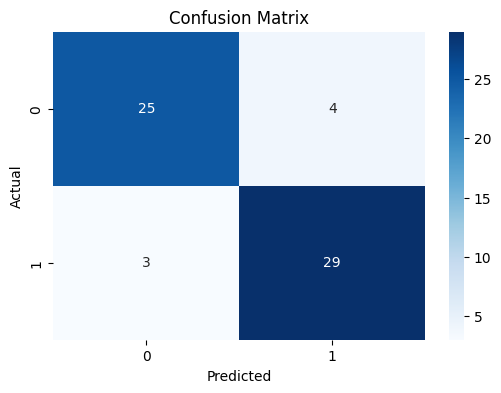

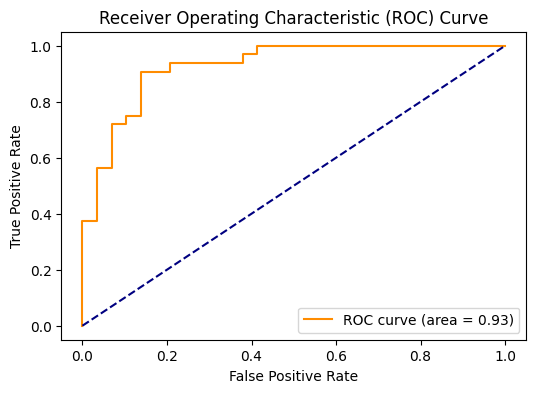

In [8]:
# Define features and target
X = df.drop(columns=['target'])
y = df['target']

# Split the data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy Score:', accuracy)

# Generate and visualize the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Compute ROC curve and AUC
y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

## Conclusion

In this notebook, we successfully loaded, visualized, and modeled the Heart Attack Data Set. The logistic regression model showed promising accuracy in predicting the target variable, and the visualizations helped uncover key relationships among the features. This baseline analysis can be extended in the future with more sophisticated models or feature engineering techniques.

We hope that this exploration provided a useful overview of the data. If you found this notebook engaging and insightful, please consider upvoting it.